Question 1 - Variables and Data Types
- Load the CSV
- Print total number of orders, total revenue, and the data types

In [152]:
import pandas as pd
df = pd.read_csv('sales_data.csv')
df.head(5)

,OrderID,Branch,Category,Product,Quantity,UnitPrice,OrderDate,CustomerID
0,1001,North,Electronics,Smartphone,1,699.99,2025-01-05,501
1,1002,South,Clothing,Jeans,2,45.50,2025-01-05,502
2,1003,West,Groceries,Milk,4,3.99,2025-01-06,503
3,1004,East,Electronics,Laptop,1,1200.00,2025-01-07,504
4,1005,North,Clothing,T-Shirt,3,15.00,2025-01-07,501


In [153]:
# column data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OrderID     15 non-null     int64  
 1   Branch      15 non-null     object 
 2   Category    15 non-null     object 
 3   Product     15 non-null     object 
 4   Quantity    15 non-null     int64  
 5   UnitPrice   15 non-null     float64
 6   OrderDate   15 non-null     object 
 7   CustomerID  15 non-null     int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 1.1+ KB


In [154]:
# total number of orders
df.shape

(15, 8)

In [171]:
# total revenue
df['Revenue'] = df['UnitPrice'] * df['Quantity']
#df.head()
df['Revenue'].sum()

np.float64(3163.8999999999996)

In [172]:
df.head(5)

,OrderID,Branch,Category,Product,Quantity,UnitPrice,OrderDate,CustomerID,Revenue,OrderValueCategory,Date
0,1001,North,Electronics,Smartphone,1,699.99,2025-01-05,501,699.99,High Value,2025-01-05
1,1002,South,Clothing,Jeans,2,45.50,2025-01-05,502,91.00,Low Value,2025-01-05
2,1003,West,Groceries,Milk,4,3.99,2025-01-06,503,15.96,Low Value,2025-01-06
3,1004,East,Electronics,Laptop,1,1200.00,2025-01-07,504,1200.00,High Value,2025-01-07
4,1005,North,Clothing,T-Shirt,3,15.00,2025-01-07,501,45.00,Low Value,2025-01-07


Question 2 - Control Statements
- if-else statement for revenue

In [156]:
def value(rev):
    if rev > 500:
        return "High Value"
    elif rev >= 200 and rev <= 500:
        return "Medium Value"
    elif rev < 200:
        return "Low Value"
    else:
        return "N/A"

df['OrderValueCategory'] = df['Revenue'].apply(value)
# df.head(5)

Question 3 - Loops
- Use a for loop to create a dictionary showing total revenue per branch

In [157]:
unique_branch_test = dict.fromkeys(df['Branch'].unique(), 0)
print(unique_branch_test)

{'North': 0, 'South': 0, 'West': 0, 'East': 0}


In [158]:
unique_branch = dict.fromkeys(df['Branch'].unique(), 0)

for i in range(len(df)) :
    branch = df.loc[i, 'Branch']
    revenue = df.loc[i, 'Revenue']
    
    if branch in unique_branch :
        unique_branch[branch] += float(revenue)
    else :
        unique_branch[branch] = float(revenue)

print(unique_branch)

{'North': 1099.99, 'South': 559.0, 'West': 202.41000000000003, 'East': 1302.5}


Question 4 - Functions
- takes a branch name as an input and returns the average order value for that branch

In [160]:
def average_order_value(branch) :
    aov = df[df['Branch'] == branch]['Revenue'].mean()
    return(aov)
    
branch = input("Enter a branch name (North, South, East, West): ")
print("AOV: ", average_order_value(branch))

Enter a branch name (North, South, East, West):  North


AOV:  274.9975


Question 5 - Exception Handling
- handle file not found error
- handle value error when converting quantity and unit price to numeric

In [162]:
def file_read(name):
    try:
        data = pd.read_csv(name)
        data.head(5)
    except FileNotFoundError:
        print("File {f} not found error".format(f=name))

file_read("fake.csv")

File fake.csv not found error


In [163]:
def convertion(col):
    try:
        df[col] = pd.to_numeric(df[col])
        print("Converted {c}".format(c=col))
    except ValueError:
        print("Column {c} cannot be converted to numeric".format(c=col))

convertion('Quantity')
convertion('UnitPrice')

Converted Quantity
Converted UnitPrice


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   OrderID             15 non-null     int64  
 1   Branch              15 non-null     object 
 2   Category            15 non-null     object 
 3   Product             15 non-null     object 
 4   Quantity            15 non-null     int64  
 5   UnitPrice           15 non-null     float64
 6   OrderDate           15 non-null     object 
 7   CustomerID          15 non-null     int64  
 8   Revenue             15 non-null     float64
 9   OrderValueCategory  15 non-null     object 
dtypes: float64(2), int64(3), object(5)
memory usage: 1.3+ KB


Question 6 - Data Visualization
1. Bar chart of total revenue per branch using MatPlotlib
2. Pie chart of order distribution by category using Seaborn
3. Line chart of daily revenue trend using Plotly

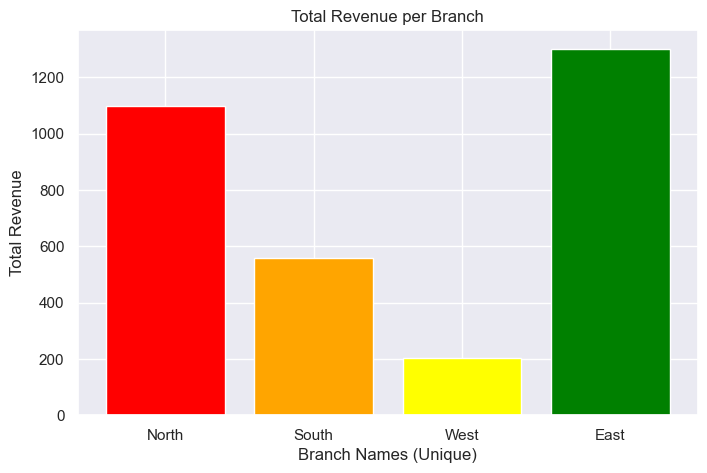

In [165]:
from matplotlib import pyplot as plt

keys = list(unique_branch.keys())
values = list(unique_branch.values())

plt.figure(figsize=(8,5))
plt.bar(keys, values, color=['Red', 'Orange', 'Yellow', 'Green'])

plt.ylabel("Total Revenue")
plt.xlabel("Branch Names (Unique)")
plt.title("Total Revenue per Branch")

plt.show()

Text(0.5, 1.0, 'Order Distribution by Each Category')

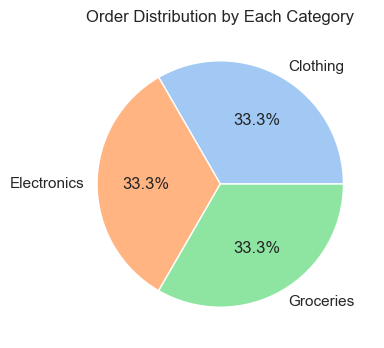

In [166]:
import seaborn as sns
from matplotlib import pyplot as plt

order_dis = df.groupby('Category')['OrderID'].count()
#print(order_dis)

sns.set_theme(palette="pastel")
plt.figure(figsize=(4,4))
order_dis.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel(' ')
plt.title("Order Distribution by Each Category")

In [167]:
import plotly.express as px
df['Date'] = pd.to_datetime(df['OrderDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   OrderID             15 non-null     int64         
 1   Branch              15 non-null     object        
 2   Category            15 non-null     object        
 3   Product             15 non-null     object        
 4   Quantity            15 non-null     int64         
 5   UnitPrice           15 non-null     float64       
 6   OrderDate           15 non-null     object        
 7   CustomerID          15 non-null     int64         
 8   Revenue             15 non-null     float64       
 9   OrderValueCategory  15 non-null     object        
 10  Date                15 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 1.4+ KB


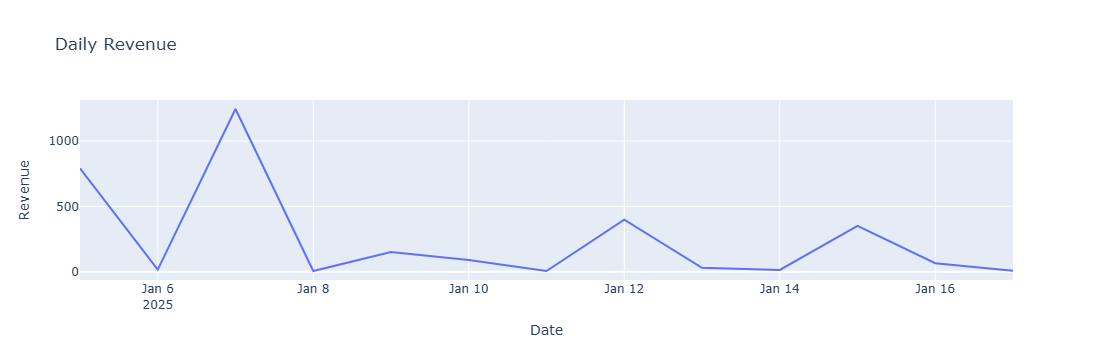

In [169]:
daily_rev = df.groupby('Date')['Revenue'].sum().reset_index()
#print(daily_rev)
fig = px.line(daily_rev, x='Date', y='Revenue', title="Daily Revenue")
fig.show()

Question 7 - Advanced Python Concepts
- user-defined InvalidBranchError when a branch not in the dataset is passed to average_order_value()

In [96]:
class InvalidBranchError(Exception):
    def __init__(self, branch, message="Branch name is invalid"):
        self.branch = branch
        self.message = message
        super().__init__(self.message)
    def __str__(self):
        return f"{self.message}, given {self.branch}"

In [100]:
def new_branch(branch):
    try:
        compare = df['Branch'] == branch
        if not compare.any():
            raise InvalidBranchError(branch)
        aov = df[compare]['Revenue'].mean()
        return(aov)
    except InvalidBranchError as e:
        print(f"Error: {e}")

In [99]:
test = input("Enter a branch name (North, South, East, West): ")
print("AOV: ", new_branch(test))

Enter a branch name (North, South, East, West):  East


AOV:  434.1666666666667
